In [ ]:
complexity_idx = int(input("INPUT 'visualization_target for complexity RUN_ID'(e.g., 20000): "))

print(f'Figure will be drawn based on the run_id_{complexity_idx} dataset')

Figure will be drawn based on the run_id_20000 dataset


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

from lib.code_complexity.cyclomatic_complexity import calculate_cyclomatic_complexity
from lib.utils.file_io import read_complexity_jsonl

import lib.stats.chowtest as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.code_complexity.tools.Result_Prep import Result_Prep as Result_Prep_C
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.figure_setting as figure_setting
from lib.visualization.plot_generator import PlotGen
mpl.rcParams.update(figure_setting.fig_setting)
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

import statsmodels.formula.api as smf
from scipy import stats

from scipy.stats import linregress, ttest_1samp
from statsmodels.stats.multitest import multipletests

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D







In [ ]:
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'
MIN_WEEK     = -104
MAX_WEEK     = +160
MIN_PRE  = 50
MIN_POST = 50

In [ ]:
tot_viz_df = pd.DataFrame()
for idx, lang in enumerate(list({lang: set_ for lang, set_ in CONSTANTS.LANG_INFO.items() if set_[1] is not None}.keys())):
    print(f'[visualizing....] start visualizing {lang} language')
    rp_c = Result_Prep_C(int(complexity_idx)+idx)
    viz_df = rp_c.data_prep_for_all(lang)
    tot_viz_df = pd.concat([tot_viz_df, viz_df], ignore_index=True)

[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:13<00:00,  4.92it/s]


[visualizing....] start visualizing javascript language


100%|██████████| 65/65 [00:07<00:00,  9.18it/s]


[visualizing....] start visualizing java language


...

100%|██████████| 65/65 [00:00<00:00, 998.48it/s]


[visualizing....] start visualizing fortran language


100%|██████████| 65/65 [00:00<00:00, 1230.64it/s]


[visualizing....] start visualizing solidity language


100%|██████████| 65/65 [00:00<00:00, 799.27it/s]


In [ ]:
panel = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] Aggreagate data for {lang} language')
    tmp = load_df(f'/mnt/hdd/mghan/so_data_availability/result/tag/run_id_{100+idx}/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp['language'] = lang
    panel = pd.concat([panel, tmp], axis = 0)
    

[Start....] Aggreagate data for python language


100%|██████████| 153/153 [00:06<00:00, 24.19it/s]


[Start....] Aggreagate data for javascript language


100%|██████████| 108/108 [00:04<00:00, 23.62it/s]


[Start....] Aggreagate data for java language


...

100%|██████████| 1/1 [00:00<00:00, 64.70it/s]


[Start....] Aggreagate data for f# language


100%|██████████| 1/1 [00:00<00:00, 116.57it/s]


[Start....] Aggreagate data for solidity language


100%|██████████| 2/2 [00:00<00:00, 60.60it/s]


In [ ]:
panel['rel_week'] = (pd.to_datetime(panel['cdate']) - datetime(2022, 11, 30)).dt.days //7
panel = panel[panel['rel_week']<0].groupby(['language'])['pct'].sum().reset_index().rename(columns = {'pct' : 'post_count'})
panel['log_post_count'] = np.log(panel['post_count'])

In [ ]:
weekly = rp_c.data_prep_for_its(tot_viz_df)

In [ ]:
weekly

,language,rel_week,log_cc_mean,n_func
0,c,-104,1.246516,741
1,c,-103,1.257209,741
2,c,-102,1.237901,595
3,c,-101,1.309187,538
4,c,-100,1.218416,569
...,...,...,...,...
4650,typescript,139,0.852078,40
4652,typescript,141,0.859478,35
4656,typescript,145,1.062935,50
4657,typescript,146,0.769529,50


In [ ]:
weekly['t']      = weekly['rel_week']
weekly['post']   = (weekly['rel_week'] >= 0).astype(int)
weekly['post_t'] = weekly['post'] * weekly['rel_week']


# ★ pre/post 데이터 충분한 언어만 선별
cov = weekly.groupby('language').agg(
    n_pre  = ('t', lambda s: (s < 0).sum()),
    n_post = ('t', lambda s: (s >= 0).sum()),
).reset_index()
keep_langs = cov[(cov['n_pre'] >= MIN_PRE) &
                 (cov['n_post'] >= MIN_POST)]['language'].tolist()

dropped = sorted(set(weekly['language'].unique()) - set(keep_langs))
weekly = weekly[weekly['language'].isin(keep_langs)].copy()

print(f"포함 언어 ({len(keep_langs)}): {sorted(keep_langs)}")
print(f"제외 언어 ({len(dropped)}): {dropped}")
print(f"기준: pre>={MIN_PRE}, post>={MIN_POST}주")
print(f"분석 데이터: {len(weekly):,}개 행")
 
print(f"n = {len(weekly):,}, 언어 = {weekly['language'].nunique()}")
print(f"기간: {weekly['rel_week'].min()} ~ {weekly['rel_week'].max()}주")
 


포함 언어 (13): ['c', 'c#', 'c++', 'go', 'java', 'javascript', 'kotlin', 'php', 'python', 'r', 'rust', 'swift', 'typescript']
제외 언어 (6): ['fortran', 'lua', 'objective-c', 'ruby', 'scala', 'solidity']
기준: pre>=50, post>=50주
분석 데이터: 3,099개 행
n = 3,099, 언어 = 13
기간: -104 ~ 155주


## 전체 언어에 대한  ITS수행

In [ ]:
weekly = weekly.sort_values(['language', 't']).reset_index(drop=True)
 
formula = f'{TARGET} ~ t + post + post_t + C(language)'
print(formula)
m = smf.wls(formula, data=weekly).fit(
    cov_type='cluster', cov_kwds={'groups': weekly['language']},
)


log_cc_mean ~ t + post + post_t + C(language)


In [ ]:
cf = weekly.copy()
cf['post'] = 0; cf['post_t'] = 0
weekly['y_cf'] = m.predict(cf)
weekly['eff_pct'] = (np.exp(weekly[TARGET] - weekly['y_cf']) - 1) * 100

def wmean(g): return np.average(g['eff_pct'], weights=g['n_func'])
t_obs = weekly.groupby('t').apply(
    lambda g: pd.Series({'eff': wmean(g)}), include_groups=False
).reset_index()

lo_p, hi_p = np.percentile(t_obs['eff'], [1, 99])
pad = (hi_p - lo_p) * 0.15
Y_LOW, Y_HIGH = lo_p - pad, hi_p + pad

p_slope = m.pvalues['post_t']


In [ ]:
def its_effect(model, t_grid):
    """ITS 효과 = β_post + β_post_t × t, 시점별 SE는 delta method"""
    β_p, β_pt = model.params['post'], model.params['post_t']
    cov = model.cov_params()
    v_p, v_pt = cov.loc['post','post'], cov.loc['post_t','post_t']
    c_p_pt    = cov.loc['post','post_t']
 
    eff = np.where(t_grid >= 0, β_p + β_pt * t_grid, 0.0)
    var = np.where(t_grid >= 0,
                   v_p + (t_grid**2)*v_pt + 2*t_grid*c_p_pt, 0.0)
    se  = np.sqrt(np.maximum(var, 0))
    return pd.DataFrame({
        't':          t_grid,
        'effect_pct': (np.exp(eff)      - 1) * 100,
        'ci_low_pct': (np.exp(eff-1.96*se) - 1) * 100,
        'ci_high_pct':(np.exp(eff+1.96*se) - 1) * 100,
    })

eff_smooth = its_effect(m, np.arange(MIN_WEEK, MAX_WEEK+1, 1))
eff_points = its_effect(m, np.arange(MIN_WEEK, MAX_WEEK+1, 4))

## 언어 개별 ITS수행

In [ ]:
BIN_SIZE     = 4
MIN_BIN      = -28       # Event Study 범위와 동일
MAX_BIN      = +39

# Bin 범위를 주 단위로 변환
MIN_WEEK = MIN_BIN * BIN_SIZE   # -112
MAX_WEEK = MAX_BIN * BIN_SIZE   # +156

lang_list = ['c',
 'c#',
 'c++',
 'go',
 'java',
 'javascript',
 'kotlin',
 'php',
 'python',
 'r',
 'rust',
 'swift',
 'typescript']

weekly_lang = weekly.copy()


def beta_to_pct(b): return (np.exp(b) - 1) * 100


its_lang_results = []
formula_lang = f'{TARGET} ~ t + post + post_t'

for lang in sorted(weekly_lang['language'].unique()):
    sub = weekly_lang[weekly_lang['language'] == lang].sort_values('t').copy()
    
    if len(sub) < 30:
        print(f"[SKIP] {lang}: n_obs={len(sub)} < 30")
        continue
    
    try:
        # m = smf.wls(formula_lang, data=sub, weights=sub['n_func']).fit(
        #     cov_type='HAC', cov_kwds={'maxlags': 8}
        # )

        m = smf.wls(formula_lang, data=sub ).fit(
            cov_type='HAC', cov_kwds={'maxlags': 4}
        )
    except Exception as e:
        print(f"[SKIP] {lang}: {e}")
        continue
    
    if m.bse.isna().any():
        print(f"[SKIP] {lang}: NaN SE")
        continue
    

    
    its_lang_results.append({
        'language':         lang,
        'n_func':           weekly_lang[weekly_lang['language'] == lang].shape[0],
        'n_obs':            len(sub),
        
        # Pre-trend
        'pre_trend':        m.params['t'],
        'pre_trend_p':      m.pvalues['t'],
        
        # Level change
        'level_change':     m.params['post'],
        'level_change_se':  m.bse['post'],
        'level_change_p':   m.pvalues['post'],
        'level_change_pct': beta_to_pct(m.params['post']),
        
        # Slope change (가장 중요)
        'slope_change':     m.params['post_t'],
        'slope_change_se':  m.bse['post_t'],
        'slope_change_p':   m.pvalues['post_t'],
        'slope_change_pct': beta_to_pct(m.params['post_t']),
        
        
        'r_squared':        m.rsquared,
    })

its_lang_df = pd.DataFrame(its_lang_results)
its_lang_df = pd.merge(its_lang_df, panel, on = 'language')
its_lang_df['post_count'] = its_lang_df['post_count'].astype(int)


In [ ]:
its_lang_df['language'].to_list()

['c',
 'c#',
 'c++',
 'go',
 'java',
 'javascript',
 'kotlin',
 'php',
 'python',
 'r',
 'rust',
 'swift',
 'typescript']

In [ ]:


# ── slope change 연 단위 + CI (delta method, post_t의 SE 직접 사용)
its_lang_df['slope_yr_pct']    = (np.exp(its_lang_df['slope_change'] * 52) - 1) * 100
its_lang_df['slope_yr_lo_pct'] = (np.exp((its_lang_df['slope_change'] - 1.96*its_lang_df['slope_change_se']) * 52) - 1) * 100
its_lang_df['slope_yr_hi_pct'] = (np.exp((its_lang_df['slope_change'] + 1.96*its_lang_df['slope_change_se']) * 52) - 1) * 100


# 색: slope change 유의성 기준 (CI가 0 포함 여부와 일치)
def categorize(row):
    if row['slope_change_p'] >= 0.05:
        return figure_setting.PALETTE['neutral']
    return figure_setting.PALETTE['accent'] if row['slope_change'] > 0 else figure_setting.PALETTE['primary']

its_lang_df['color_slope'] = its_lang_df.apply(categorize, axis=1)
its_lang_df['alpha'] = its_lang_df['color_slope'].apply(
    lambda c: 0.55 if c == figure_setting.PALETTE['neutral'] else 1.0)

sorted_s = its_lang_df.sort_values('log_post_count', ascending=True).reset_index(drop=True)

AttributeError: 'PlotGen' object has no attribute 'set_ticks'

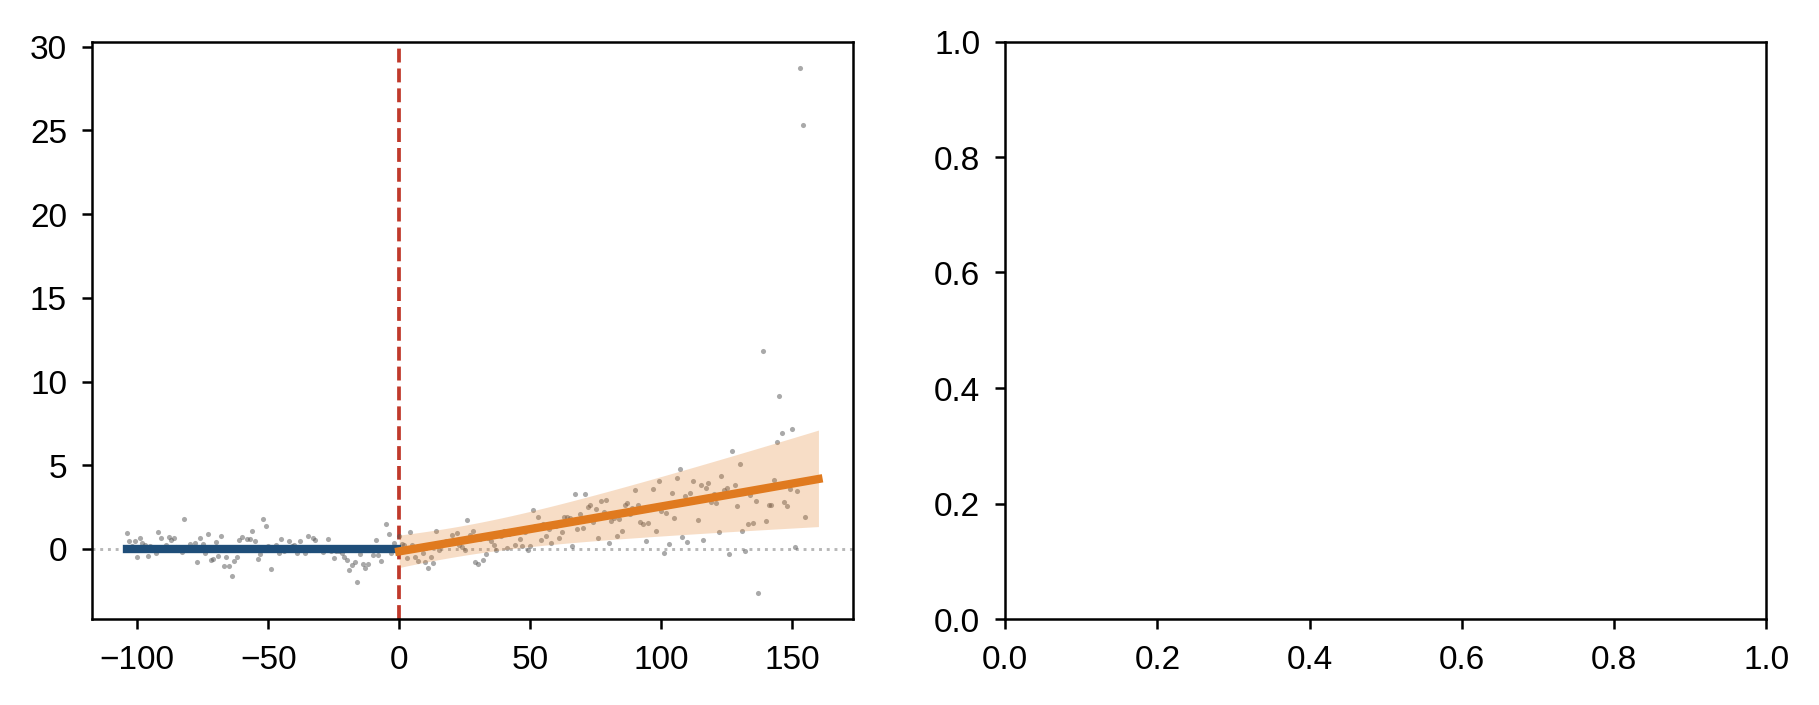

In [ ]:

fig = plt.figure(figsize=(7.2, 2.5), dpi=300)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

# a: 3패널 (각 2칸씩)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])


plotgen = PlotGen()

ax_a.axhline(0, color='#999', lw=0.7, ls=':', alpha=0.7, zorder=0)

x = t_obs['t']
y = t_obs['eff']

plotgen.draw_scatter_plot(ax_a, x, y)
plotgen.draw_line_plot(          ax_a,    eff_smooth.loc[eff_smooth['t'] <  0, 't'], \
                                        eff_smooth.loc[eff_smooth['t'] <  0, 'effect_pct'], \
                                        color=figure_setting.PALETTE['primary'])
plotgen.draw_line_plot(          ax_a,    eff_smooth.loc[eff_smooth['t'] >=  0, 't'], \
                                        eff_smooth.loc[eff_smooth['t'] >=  0, 'effect_pct'], \
                                        color=figure_setting.PALETTE['accent'])

plotgen.fill_confidence_interval(ax_a,    eff_smooth.loc[eff_smooth['t'] >= 0, 't'],\
                                        eff_smooth.loc[eff_smooth['t'] >= 0, 'ci_low_pct'], \
                                        eff_smooth.loc[eff_smooth['t'] >= 0, 'ci_high_pct'], \
                                        color=figure_setting.PALETTE['accent'])
plotgen.draw_vertical_line(ax_a, x)
plotgen.set_ticks(ax_a)
plotgen.set_title_two_lines(ax_a, title_text='Changes in Code Complexity : Overall', p_value= float(p_slope))
ax_a.set_ylim(Y_LOW, Y_HIGH)
ax_a.set_xlabel('Weeks relative to ChatGPT release')
ax_a.set_ylabel('Changes in Complexity (% per week)')

# ===================================================================


ax_b.axvline(0, color='#333', lw=0.6, zorder=1)
# ax.axvline(pool_slope_yr, color=figure_setting.PALETTE['event'], lw=0.9, ls='--', zorder=1)

for i, row in sorted_s.iterrows():
    # 95% CI 막대
    ax_b.plot([row['slope_yr_lo_pct'], row['slope_yr_hi_pct']], [i, i],
            color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['slope_yr_lo_pct'], row['slope_yr_hi_pct']]:
        ax_b.plot([xe, xe], [i-0.18, i+0.18],
                color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    # 점추정
    ax_b.scatter(row['slope_yr_pct'], i, s=46,
               facecolor=row['color_slope'], edgecolor='white',
               linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_b.set_yticks(np.arange(len(sorted_s)))
ax_b.set_yticklabels([f"{r['language']}"
                    for _, r in sorted_s.iterrows()])
# ax_b.set_xlabel('Post-ChatGPT slope change (% per year, 95% CI)')

for s in ['top', 'right']: ax_b.spines[s].set_visible(False)
ax_b.spines['left'].set_visible(False)
ax_b.spines['bottom'].set_position(('outward', 3))
ax_b.tick_params(axis='y', length=0)
ax_b.set_xlabel('Changes in Complexity (% per year)')
plotgen.set_title_two_lines(ax_b, title_text='Changes in Code Complexity : Language')

plt.savefig('./fig/Fig4_AB.pdf', bbox_inches='tight', dpi=300)
